# Commodity Equity Alpha

The main approach in this model is examining and trading the relationship between physical producers / users equity alpha and commodities returns. The equity alpha for commodities producer is the excess return attribute to the individual companies. Equity investors may be attributing excess returns to commodity companies which the commodities market doesn't fully price in.

We'll first by using various commodity ETFs and their respective Commodity Futures. 

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

# Preparing data

In [2]:
df_eq = (pd.read_parquet(
    path = r"data/eq_px.parquet").
    query("variable == 'Adj Close'").
    pivot(index = "date", columns = "ticker", values = "value").
    pct_change().
    reset_index().
    melt(id_vars = ["date", "SPY"]).
    dropna())

In [4]:
df_fut = (pd.read_parquet(
    path = r"data/commod_px.parquet").
    assign(security = lambda x: x.security.str.split("1").str[0].str.strip()).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change().
    reset_index().
    melt(id_vars = ["date"], var_name = "fut_ticker", value_name = "fut_rtn").
    dropna().
    assign(date = lambda x: pd.to_datetime(x.date).dt.date))

In [5]:
path     = os.path.join(r"data/tickers.xlsx")
df_namer = (pd.read_excel(
    io = path, sheet_name = "Sheet2")
    [["fut_ticker", "fut_name"]])

In [6]:
df_relationship = pd.read_excel(io = r"data/tickers.xlsx", sheet_name = "Sheet2")

In [7]:
df_ticker = (pd.read_excel(
    io         = r"data/tickers.xlsx", 
    sheet_name = "Sheet2").
    assign(
        tmp       = lambda x: x.Name.str.replace("VanEck", "").str.replace("ETF", "").str.replace("and", "&").str.replace("Metals", ""),
        group_var = lambda x: x.Ticker + " " + x.fut_ticker))

# Defining the model

First start by seperating out the alpha in equities. In this case use a 30 day rolling OLS regression and SPY as a benchmark. 

In [8]:
def _get_ols(df: pd.DataFrame, window: int = 30) -> pd.DataFrame: 
    
    df_out = (RollingOLS(
        endog  = df.value,
        exog   = sm.add_constant(df.SPY),
        window = window).
        fit().
        params.
        rename(columns = {"SPY": "beta"}).
        merge(right = df, how = "inner", on = ["date"]))
    
    return df_out

In [9]:
df_alpha = (df_eq.set_index(
    "date").
    groupby("ticker").
    apply(_get_ols, include_groups = False).
    reset_index().
    dropna())

Below is the rolling alphas of the commodity etfs to the SPY.

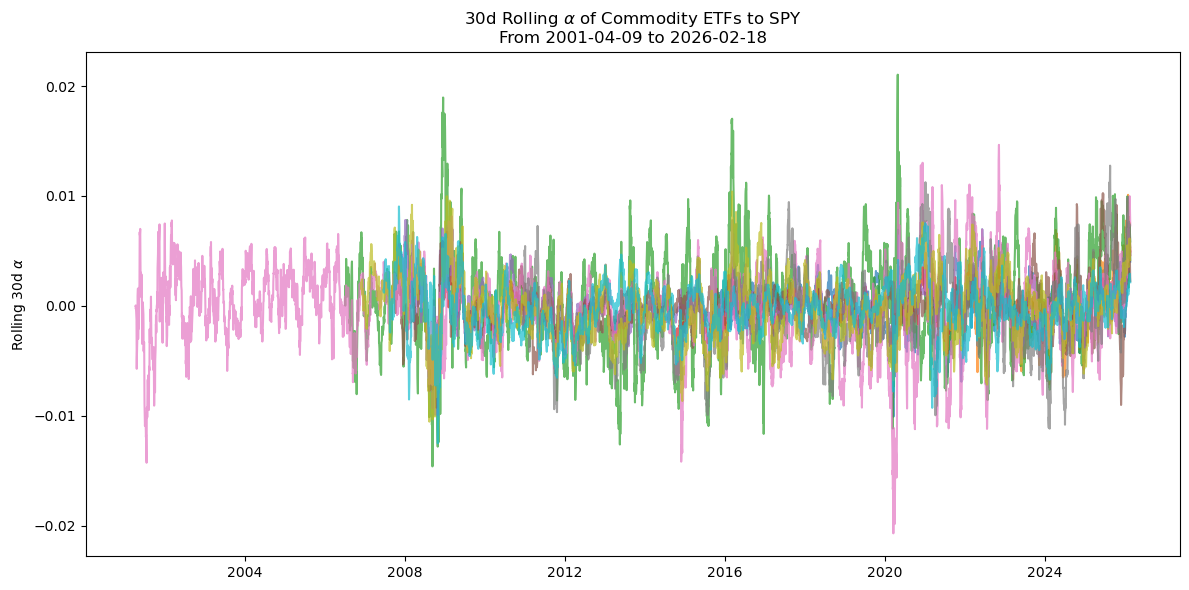

In [10]:
(df_alpha.pivot(
    index = "date", columns = "ticker", values = "const").
    plot(
        ylabel  = r"Rolling 30d $\alpha$",
        legend  = False,
        xlabel  = "",
        figsize = (12,6),
        alpha   = 0.7,
        title   = r"30d Rolling $\alpha$ of Commodity ETFs to SPY" + "\nFrom {} to {}".format(
            df_alpha.date.min(),
            df_alpha.date.max())))

plt.tight_layout()

In [11]:
df_combined = (df_relationship.rename(
    columns = {"Ticker": "ticker"}).
    assign(Name = lambda x: x.Name.str.replace("VanEck", "").str.replace("ETF", "")).
    merge(right = df_alpha, how = "inner", on = ["ticker"]).
    merge(right = df_fut, how = "inner", on = ["fut_ticker", "date"]))

In [12]:
def _get_resid(df: pd.DataFrame, q: int = 10) -> pd.DataFrame: 
    
    df_tmp = df.sort_index()
    df_out = (sm.OLS(
        endog  = df_tmp.fut_rtn,
        exog   = sm.add_constant(df_tmp.const)).
        fit().
        resid.
        to_frame(name = "resid").
        assign(
            lag_resid = lambda x: x.resid.shift(),
            decile    = lambda x: pd.qcut(x = x.resid, q = q, labels = [i + 1 for i in range(q)]).shift()).
        merge(right = df, how = "inner", on = ["date"]))
    
    return df_out

df_signal = (df_combined.assign(
    group_var = lambda x: x.ticker + " " + x.fut_ticker).
    set_index("date").
    groupby("group_var").
    apply(_get_resid, include_groups = False).
    reset_index())

In [13]:
def _model(df: pd.DataFrame) -> pd.DataFrame: 
    
    df_tmp = df.sort_index()
    model1 = (sm.OLS(
        endog  = df_tmp.fut_rtn,
        exog   = sm.add_constant(df_tmp.alpha)).
        fit())
    
    df_param_val = (model1.params.to_frame(
        name = "param_val").reset_index())
    
    df_pvalue = (model1.pvalues.to_frame(
        name = "pvalue").reset_index())
    
    df_tstat = (model1.tvalues.to_frame(
        name = "tstat").reset_index())
    
    df_out = (df_param_val.merge(
        right = df_pvalue, how = "inner", on = ["index"]).
        merge(right = df_tstat, how = "inner", on = ["index"]))
    
    return df_out

def _get_coefs(df: pd.DataFrame, q: int = 10) -> pd.DataFrame: 
    
    df_lag0 = _model(df).assign(model = "lag_0")
    df_lag  = df.sort_index().assign(alpha = lambda x: x.alpha.shift()).dropna()
    df_lag1 = _model(df_lag).assign(model = "lag_1")
    
    df_out = pd.concat([df_lag0, df_lag1])
    return df_out

df_coefs = (df_combined.assign(
    group_var = lambda x: x.ticker + " " + x.fut_ticker).
    set_index("date").
    rename(columns = {"const": "alpha"}).
    groupby("group_var").
    apply(_get_coefs))

Then we pass those rolling alphas into a regression against their respective commodities. Below is the number of accepted regressions. 

In [14]:
display(df_coefs.assign(
    tmp = lambda x: np.where((x.pvalue < 0.1) & (np.abs(x.tstat) > 1.6), 1, 0))
    [["index", "tmp", "model"]].
    reset_index().
    drop(columns = ["level_1", "group_var"]).
    rename(columns = {
        "index": "Param",
        "model": "Lag"}).
    replace({
        "alpha": r"$\alpha$",
        "const": r"$\beta$",
        "lag_0": "No Lag",
        "lag_1": "Lagged"}).
    groupby(["Param", "Lag"]).
    agg(["sum", "count"])
    ["tmp"].
    rename(columns = {
        "sum"  : "good_params",
        "count": "full_count"}).
    assign(tmp = lambda x: x.good_params / x.full_count).
    rename(columns = {
        "good_params": "Stat. Sig.",
        "full_count" : "Total",
        "tmp"        : "Ratio"}).
    apply(lambda x: np.round(x,3)))

Stat. Sig.  Total  Ratio
Param    Lag                             
$\alpha$ Lagged          19     52  0.365
         No Lag          39     52  0.750
$\beta$  Lagged          18     52  0.346
         No Lag          21     52  0.404

# Trading the Residual of OLS Model

In [15]:
df_signal_rtn = (df_signal.assign(
    signal_rtn = lambda x: -np.sign(x.lag_resid) * x.fut_rtn).
    rename(columns = {"group_var": ""}))

Here is the results of trading the residuals of that regression

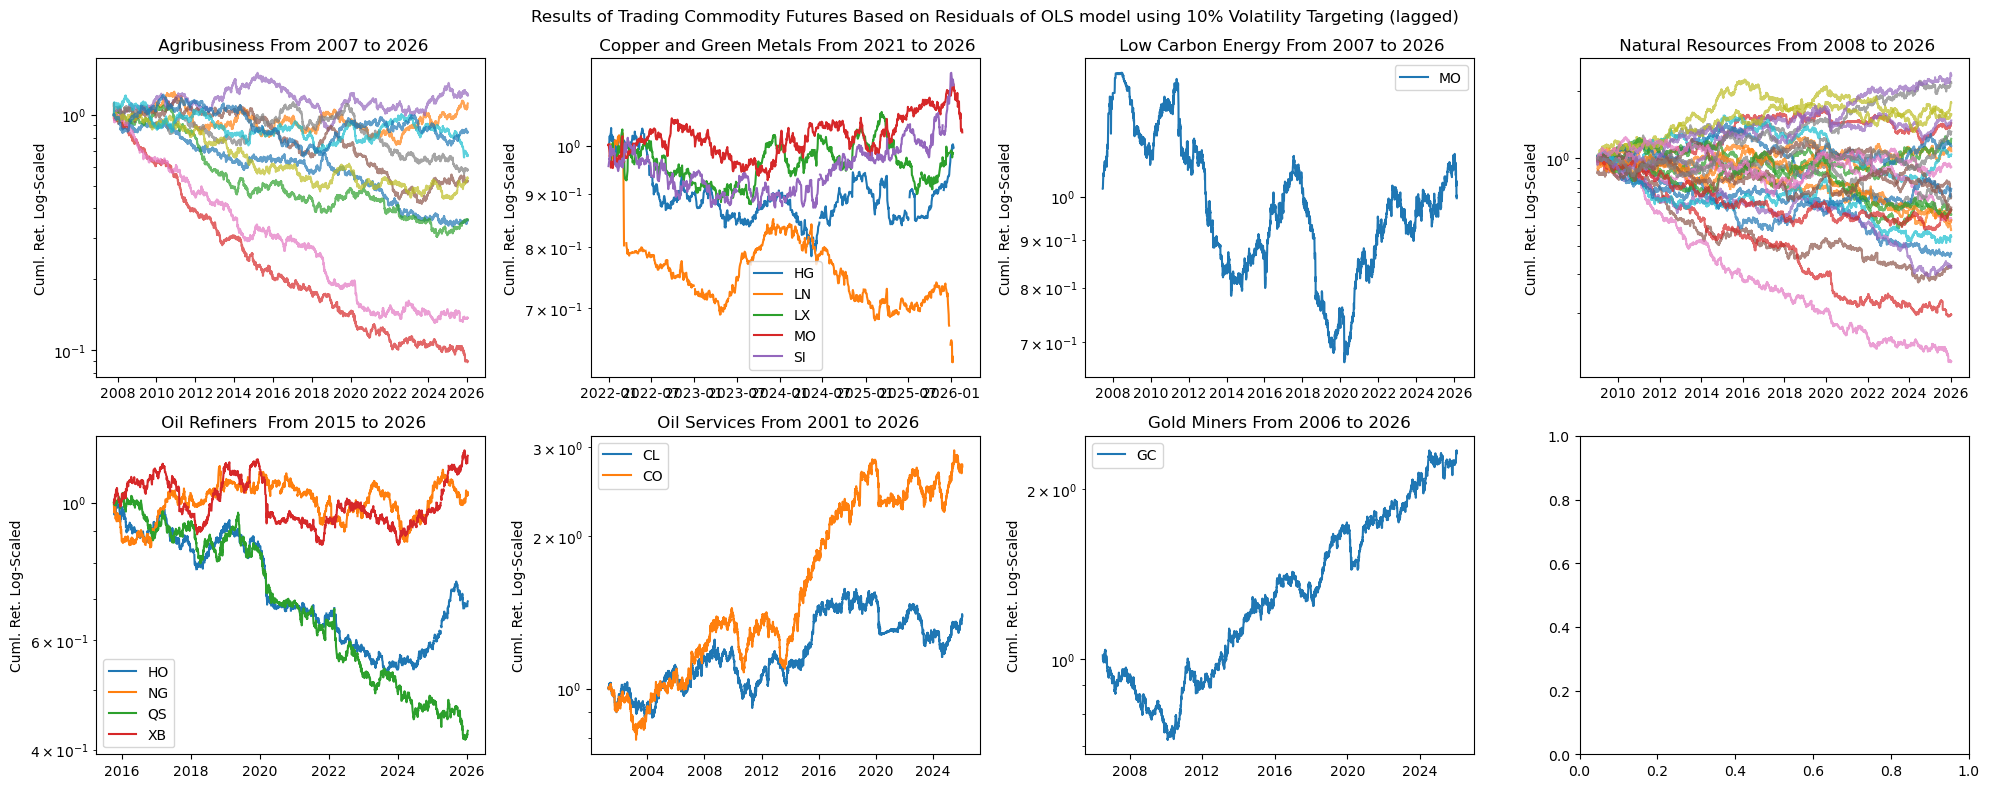

In [45]:
groups    = df_signal_rtn.Name.drop_duplicates().sort_values().to_list()
const     = 2
fig, axes = plt.subplots(ncols = 4, nrows = 2, figsize = (10 * const, 4 * const)) 

for group, ax in zip(groups, axes.flatten()):

    df_tmp_wider = (df_signal_rtn.query(
        "Name == @group").
        drop(columns = [""]).
        rename(columns = {"fut_ticker": ""}).
        pivot(index = "date", columns = "", values = "signal_rtn").
        apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
        apply(lambda x: np.where(np.abs(x) > 0.2, np.nan, x)).
        apply(lambda x: np.cumprod(1 + x)))

    tickers = df_tmp_wider.columns.to_list()
    
    if len(tickers) > 5:
        legend_bool = False
        alpha_level = 0.7
    
    else:
        legend_bool = True
        alpha_level = 1

    df_tmp_wider.plot(
        ax     = ax,
        legend = legend_bool,
        alpha  = alpha_level,
        logy   = True,
        xlabel = "",
        ylabel = "Cuml. Ret. Log-Scaled",
        title  = group + "From {} to {}".format(
            df_tmp_wider.index.min().year,
            df_tmp_wider.index.max().year))

fig.suptitle("Results of Trading Commodity Futures Based on Residuals of OLS model using 10% Volatility Targeting (lagged)")
plt.tight_layout()
fig.savefig(r"latex/NaiveTradingOLS.png", dpi = 600)

In [46]:
df_signal_sharpe = (df_signal_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = [("date", "")]).
    rename(columns = {("date", ""): "date"}).
    drop(columns = ["date"]).
    dropna().
    assign(Name = lambda x: x.Name.str.strip()).
    groupby(["Name", "fut_ticker"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index())

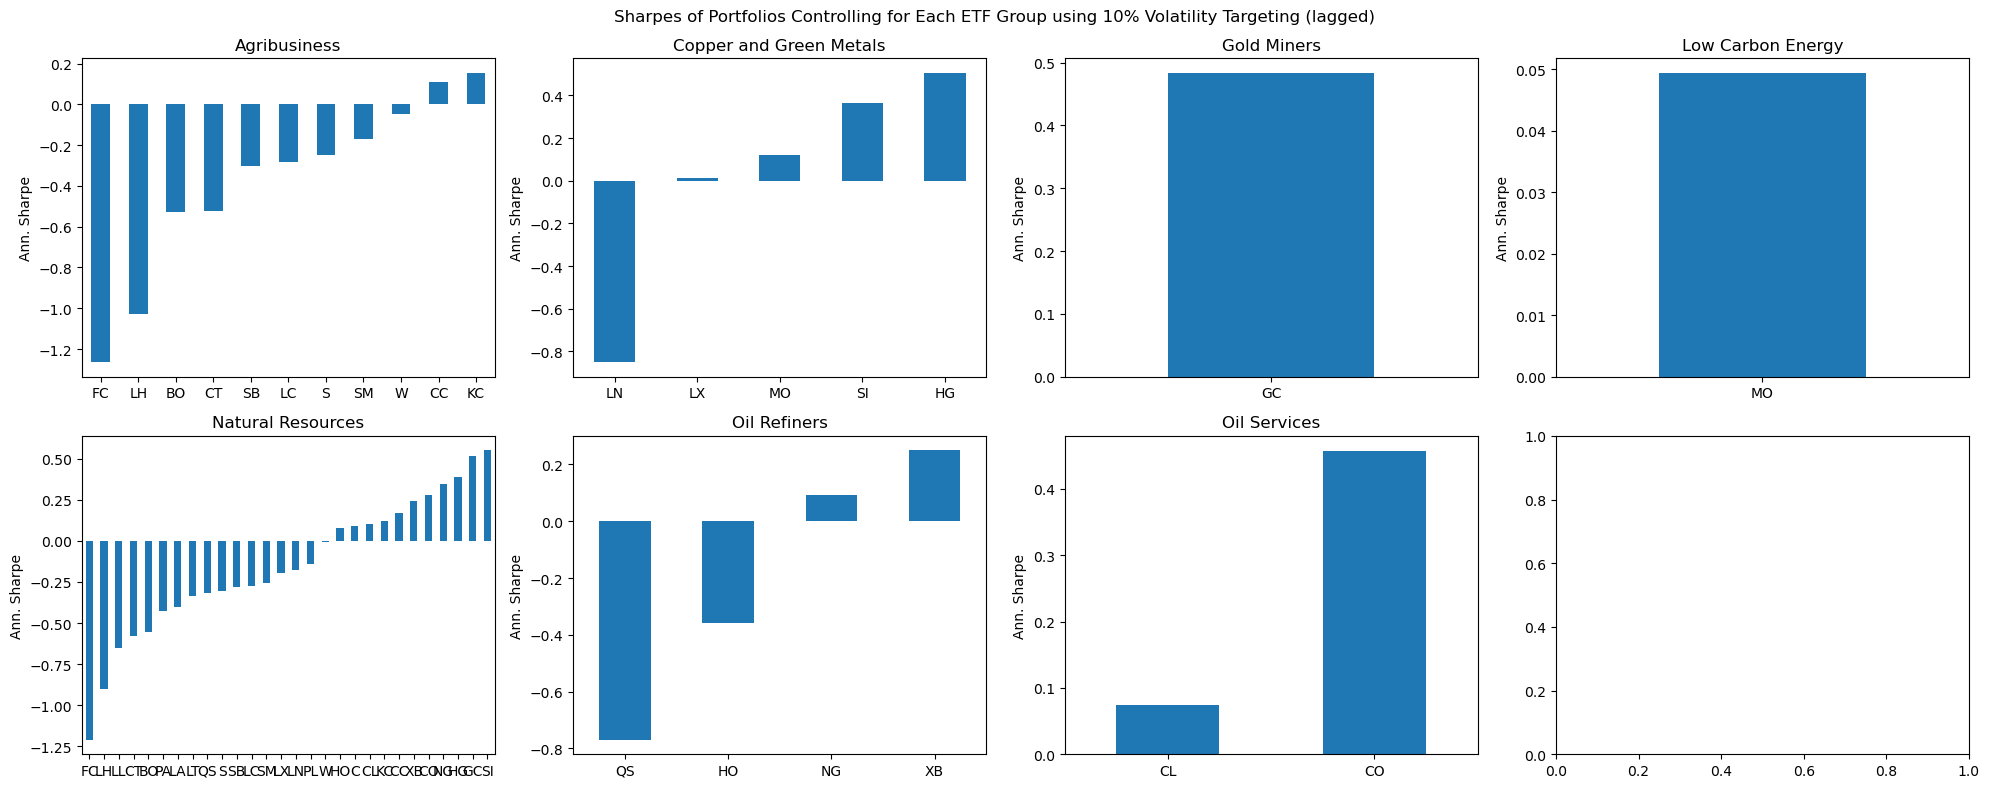

In [61]:
names     = df_signal_sharpe.Name.drop_duplicates().sort_values().to_list()
const     = 2
fig, axes = plt.subplots(ncols = 4, nrows = 2, figsize = (10 * const, 4 * const)) 

for name, ax in zip(names, axes.flatten()):

    (df_signal_sharpe.query(
        "Name == @name").
        set_index("fut_ticker").
        sort_values("value").
        drop(columns = ["Name"]).
        plot(
            kind   = "bar",
            ax     = ax,
            legend = False,
            rot    = 0,
            xlabel = "",
            ylabel = "Ann. Sharpe",
            title  = name))


fig.suptitle("Sharpes of Portfolios Controlling for Each ETF Group using 10% Volatility Targeting (lagged)")
plt.tight_layout()

# Trading Optimized Residuals of OLS Model

In [73]:
df_decile_sharpe = (df_signal[
    ["group_var", "decile", "fut_rtn"]].
    dropna().
    groupby(["group_var", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"fut_rtn": "sharpe"}))

In [74]:
df_grouper = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(group = lambda x: np.where(x.decile <= 2, "lower", "upper")))

In [75]:
df_opt_signal = (df_grouper[
    ["group_var", "group", "sharpe"]].
    assign(sharpe = lambda x: np.where(np.abs(x.sharpe) > 0.2, x.sharpe, 0)).
    groupby(["group_var", "group"]).
    agg("prod").
    reset_index().
    assign(scaler = lambda x: np.where(x.sharpe > 0, 1, np.nan)).
    drop(columns = ["sharpe"]).
    merge(right = df_grouper, how = "inner", on = ["group_var", "group"]).
    assign(signal = lambda x: x.scaler * x.sharpe).
    dropna())

In [95]:
df_opt_rtn = (df_signal.merge(
    right = df_opt_signal, how = "right", on = ["decile", "group_var"]).
    assign(
        Name       = lambda x: x.Name.str.replace("xa0", "").str.strip(),
        signal_rtn = lambda x: np.sign(x.signal) * x.fut_rtn))

In [104]:
df_opt_rsk_rtn = (df_opt_rtn.pivot(
    index = "date", columns = "group_var", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date").
    assign(
        group  = lambda x: x.group_var.str.split(" ").str[0],
        ticker = lambda x: x.group_var.str.split(" ").str[1]).
    dropna())

In [105]:
renamer = (df_signal[
    ["ticker", "Name"]].
    assign(Name = lambda x: x.Name.str.strip()).
    drop_duplicates().
    set_index("ticker").
    Name.
    to_dict())

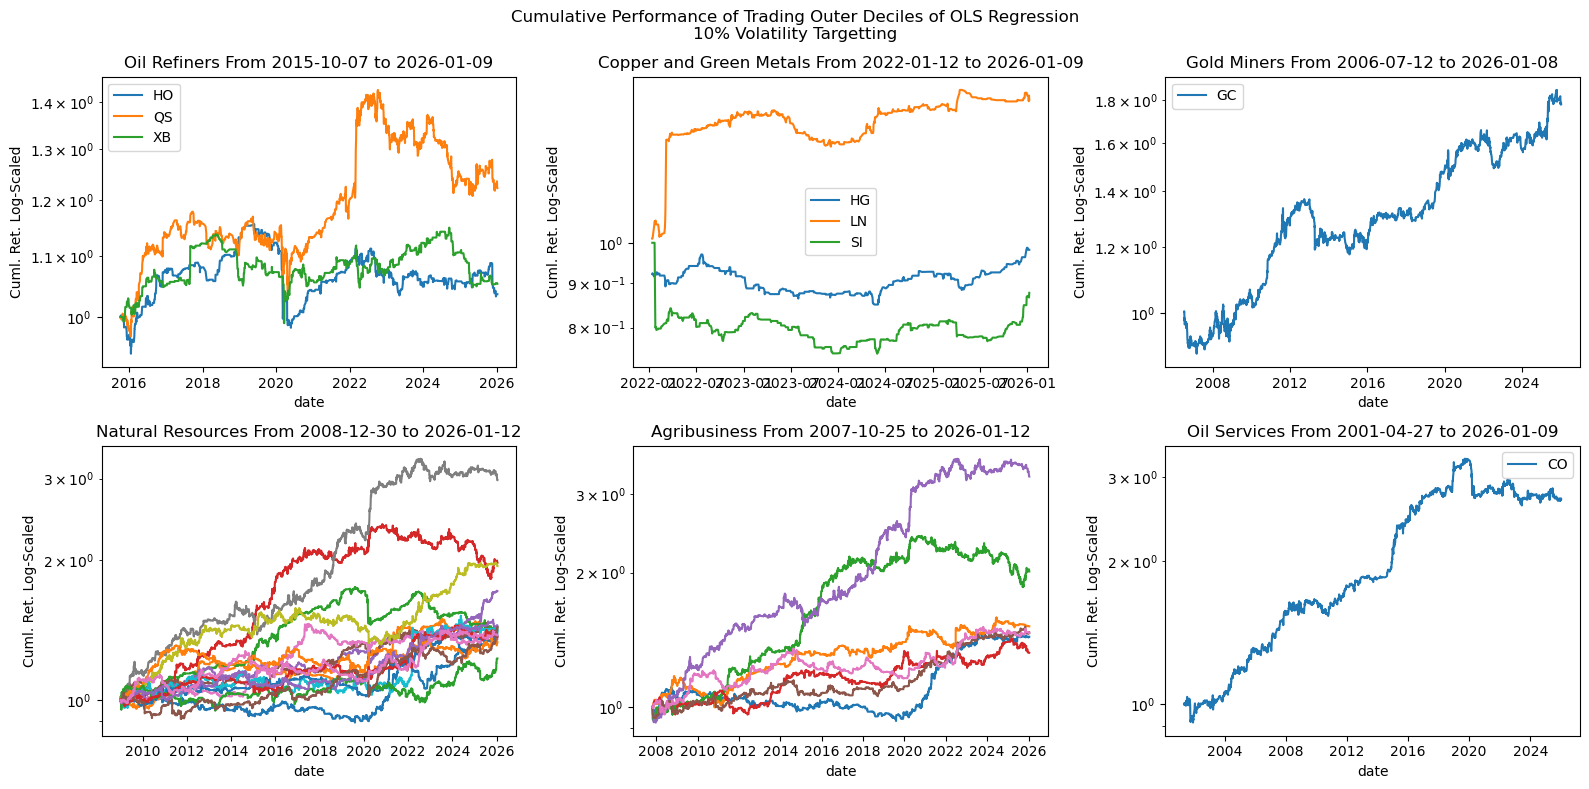

In [107]:
groups    = df_opt_rsk_rtn.group.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 3, nrows = 2, figsize = (16,8))

for group, ax in zip(groups, axes.flatten()): 
    
    df_tmp = (df_opt_rsk_rtn.query(
        "group == @group").
        rename(columns = {"ticker": ""}).
        query("value <= 0.4").
        pivot(index = "date", columns = "", values = "value").
        fillna(0).
        apply(lambda x: np.cumprod(1 + x)))

    if len(df_tmp.columns.to_list()) > 5: 
        legend_bool = False
    else: 
        legend_bool = True
    
    (df_tmp.
        plot(
            logy   = True,
            ax     = ax,
            legend = legend_bool,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = "{} From {} to {}".format(
                renamer[group],
                df_tmp.index.min(),
                df_tmp.index.max())))
    
fig.suptitle("Cumulative Performance of Trading Outer Deciles of OLS Regression\n10% Volatility Targetting")
plt.tight_layout()

In [108]:
df_opt_rtn_wider = (df_opt_rtn.pivot(
    index = "date", columns = "group_var", values = "signal_rtn"))

In [109]:
df_lag1 = (df_opt_rtn_wider.
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date").
    assign(
        raw_rtn = lambda x: x.value.fillna(0),
        group   = "lag_1").
    rename(columns = {"value": "adj_rtn"}))

df_lag0 = (df_opt_rtn_wider.
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std()* np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date").
    assign(
        raw_rtn = lambda x: x.value.fillna(0),
        group   = "lag_0").
    rename(columns = {"value": "adj_rtn"}))

In [110]:
df_namer = (df_signal[
    ["group_var", "Name", "fut_ticker"]].
    drop_duplicates())

In [111]:
(pd.concat([
    df_lag1, df_lag0]).
    melt(id_vars = ["date", "group_var", "group"]).
    dropna().
    drop(columns = ["date"]).
    merge(right = df_namer, how = "inner", on = ["group_var"]).
    drop(columns = ["group_var"]).
    groupby(["Name", "fut_ticker", "group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "group"     : "Target Type",
        "fut_ticker": "Fut",
        "variable"  : ""}).
    replace({
        "lag_0"   : "Perfect Targetting",
        "lag_1"   : "Vol Targetting",
        "adj_rtn" : "Adj. Ret",
        "raw_rtn" : "Raw Return"}).
    pivot(index = ["Name", "Fut"], columns = ["Target Type", ""], values = "value").
    apply(lambda x: np.round(x,3)))

Target Type                   Perfect Targetting            Vol Targetting  \
                                        Adj. Ret Raw Return       Adj. Ret   
Name                      Fut                                                
 Agribusiness             BO               0.760      0.313          1.031   
                          CT               1.041      0.429          1.133   
                          FC               1.038      0.604          0.979   
                          KC               0.898      0.370          0.785   
                          LH               1.752      1.017          1.689   
                          S                1.096      0.451          1.103   
                          SM               1.060      0.437          1.094   
 Copper and Green Metals  HG               1.119      0.215         -0.104   
                          LN               1.730      0.465          1.422   
                          SI               1.651      0.318         -0.519   
 Natural Resources        BO               0.940      0.375          0.987   
                          C                1.159      0.461          1.158   
                          CO               1.297      0.522          1.075   
                          FC               1.064      0.599          1.073   
                          GC               1.900      0.753          1.642   
                          HG               1.255      0.499          1.096   
                          LC               0.976      0.388          0.983   
                          LH               1.719      0.965          1.677   
                          LL               1.148      0.642          1.081   
                          LN               0.497      0.278          0.499   
                          LT               1.253      0.495          1.117   
                          PA               0.821      0.327          0.840   
                          PL               0.281      0.112          0.589   
                          QS               1.005      0.405          0.966   
                          S                1.271      0.505          1.220   
                          SI               1.384      0.550          1.078   
                          SM               1.068      0.425          1.040   
 Oil Refiners             HO               0.427      0.123          0.247   
                          QS               0.679      0.301          0.540   
                          XB               0.251      0.072          0.349   
 Oil Services             CO               1.135      0.777          1.021   
Gold Miners               GC               0.912      0.550          0.781   

Target Type                               
                              Raw Return  
Name                      Fut             
 Agribusiness             BO       0.424  
                          CT       0.466  
                          FC       0.570  
                          KC       0.323  
                          LH       0.981  
                          S        0.454  
                          SM       0.450  
 Copper and Green Metals  HG      -0.020  
                          LN       0.382  
                          SI      -0.100  
 Natural Resources        BO       0.393  
                          C        0.460  
                          CO       0.433  
                          FC       0.604  
                          GC       0.651  
                          HG       0.436  
                          LC       0.391  
                          LH       0.941  
                          LL       0.604  
                          LN       0.279  
                          LT       0.441  
                          PA       0.334  
                          PL       0.235  
                          QS       0.389  
                          S        0.485  
                          SI       0.429  
                      

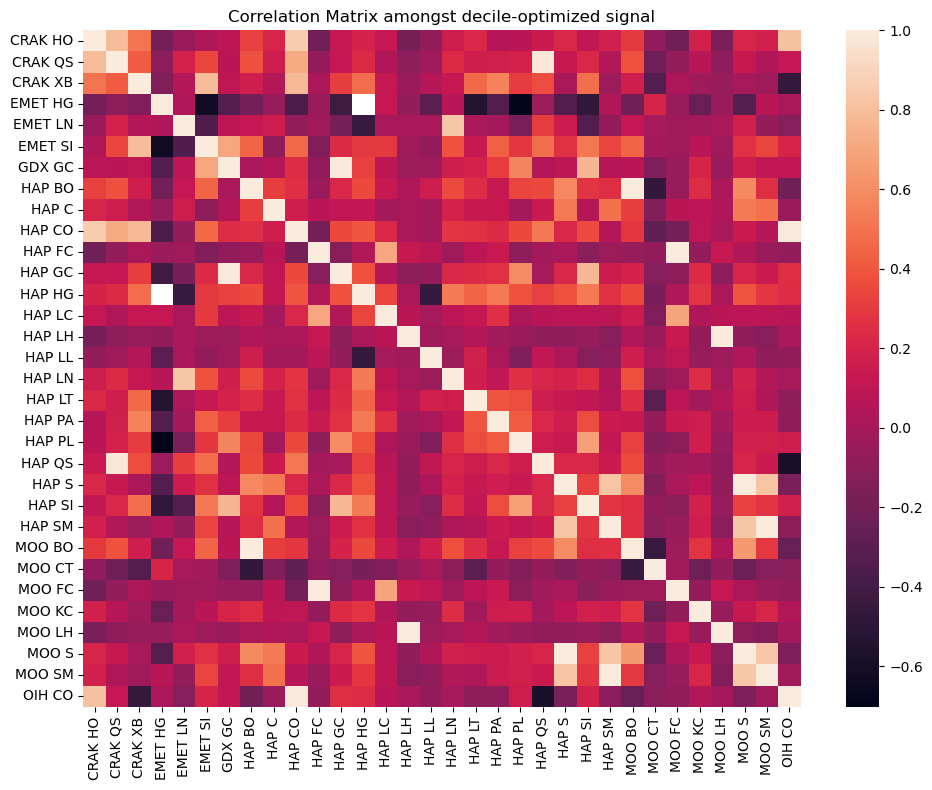

In [112]:
df_corr = (df_opt_rsk_rtn.pivot(
    index = "date", columns = "group_var", values = "value").
    corr())

fig, axes = plt.subplots(figsize = (10,8))

sns.heatmap(
    data  = df_corr,
    cbar  = True,
    annot = False)

axes.set_xlabel("")
axes.set_ylabel("")

axes.set_title("Correlation Matrix amongst decile-optimized signal")
plt.tight_layout()

In [113]:
df_name_rtn = (df_opt_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.4, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", "")], value_name = "rtn").
    rename(columns = {("date", ""): "date"}).
    drop(columns = ["fut_ticker"]).
    dropna().
    groupby(["date", "Name"]).
    agg("mean").
    assign(group = "vol_target"))

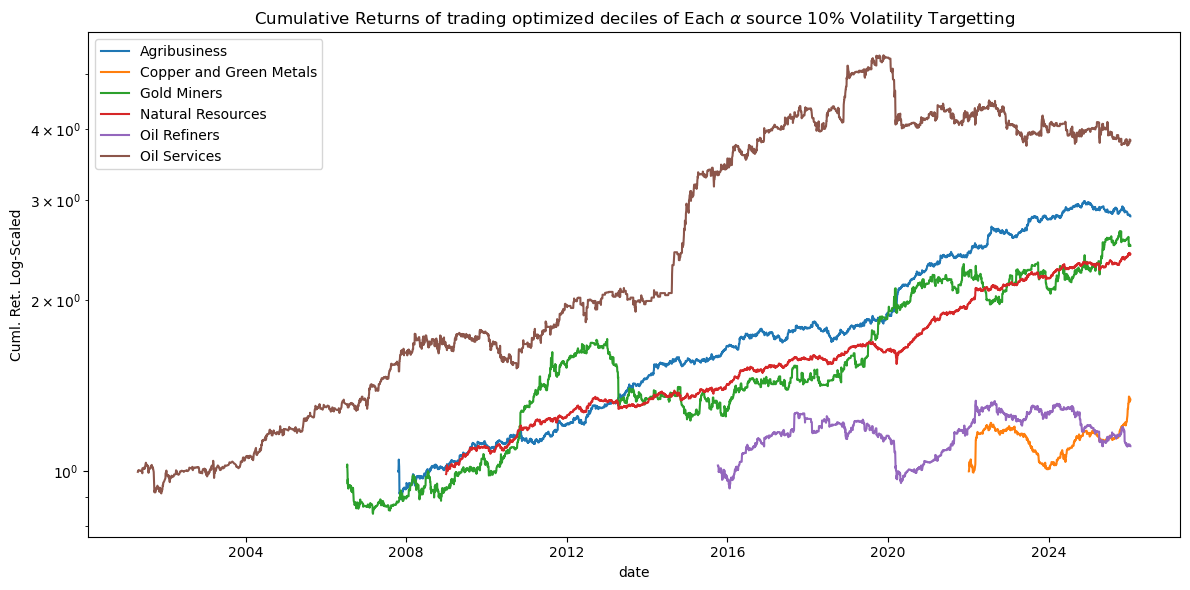

In [114]:
(df_name_rtn.
    reset_index().
    rename(columns = {"Name": ""}).
    pivot(index = "date", columns = "", values = "rtn").
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        figsize = (12,6),
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = r"Cumulative Returns of trading optimized deciles of Each $\alpha$ source 10% Volatility Targetting"))

plt.tight_layout()

In [115]:
df_perf_name_rtn = (df_opt_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.4, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", "")], value_name = "rtn").
    rename(columns = {("date", ""): "date"}).
    drop(columns = ["fut_ticker"]).
    dropna().
    groupby(["date", "Name"]).
    agg("mean").
    assign(group = "perf"))

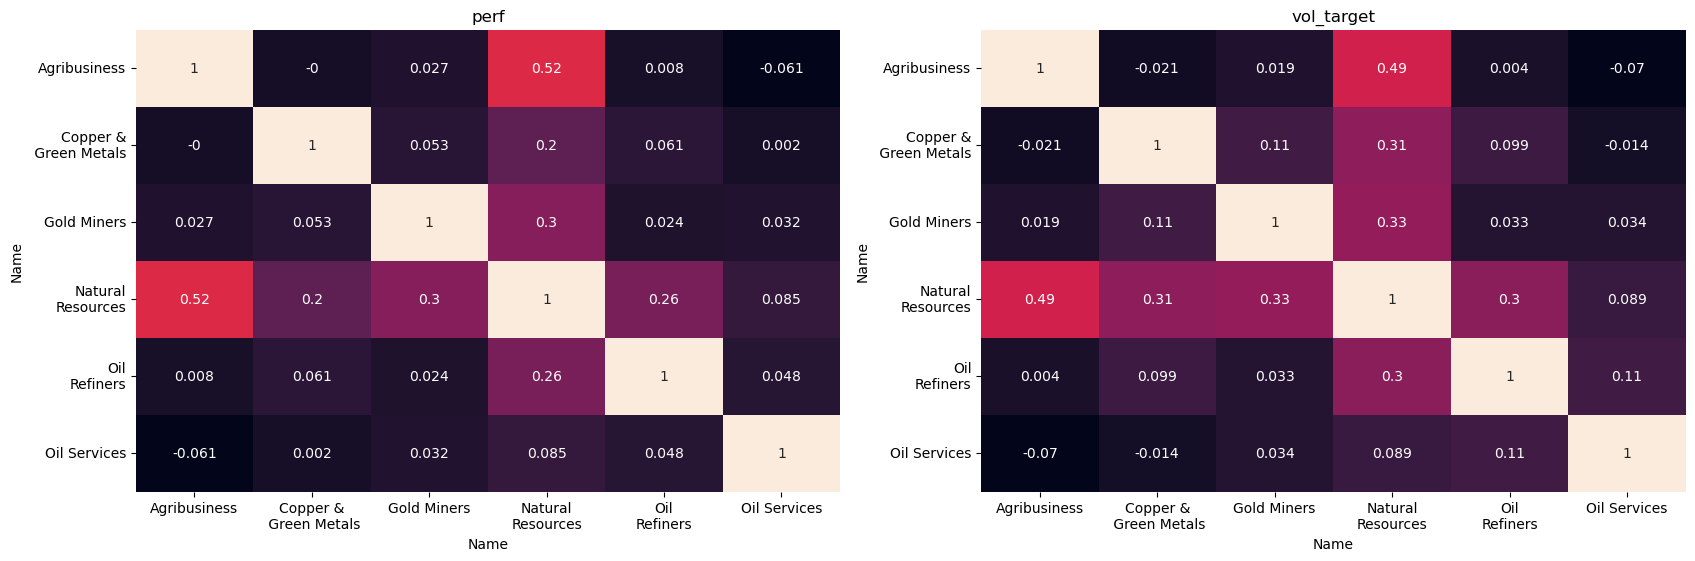

In [116]:
df_combined = (pd.concat([
    df_perf_name_rtn, df_name_rtn]).
    reset_index())

groups    = df_combined.group.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(groups), figsize = (20,6)) 

for group, ax in zip(groups, axes.flatten()): 

    df_corr = (df_combined.query(
        "group == @group").
        assign(Name = lambda x: x.Name.str.replace("and", "&\n").str.replace("l R", "l\nR")).
        pivot(index = "date", columns = "Name", values = "rtn").
        corr().
        apply(lambda x: np.round(x,3)))

    sns.heatmap(
        data  = df_corr,
        annot = True,
        ax    = ax,
        cbar  = False)

    ax.set_title(group)

In [117]:
display(pd.concat([
    df_perf_name_rtn, df_name_rtn]).
    reset_index().
    rename(columns = {"rtn": "raw_rtn"}).
    assign(adj_rtn = lambda x: np.where(x.raw_rtn == 0, np.nan, x.raw_rtn)).
    melt(id_vars = ["date", "Name", "group"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["Name", "group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "group"   : "Vol. Target",
        "variable": ""}).
    replace({
        "perf"      : "Perfect Targetting",
        "vol_target": "Vol Targetting",
        "raw_rtn"   : "Raw Sharpe",
        "adj_rtn"   : "Adj Sharpe"}).
    pivot(index = "Name", columns = ["Vol. Target", ""], values = "value").
    apply(lambda x: np.round(x,3)))

Vol. Target             Perfect Targetting            Vol Targetting  \
                                Adj Sharpe Raw Sharpe     Adj Sharpe   
Name                                                                   
Agribusiness                         1.250      1.148          1.279   
Copper and Green Metals              1.693      1.304          1.231   
Gold Miners                          0.969      0.616          0.792   
Natural Resources                    1.639      1.625          1.430   
Oil Refiners                         0.527      0.384          0.234   
Oil Services                         1.064      0.727          0.966   

Vol. Target                         
                        Raw Sharpe  
Name                                
Agribusiness                 1.174  
Copper and Green Metals      0.947  
Gold Miners                  0.504  
Natural Resources            1.417  
Oil Refiners                 0.171  
Oil Services                 0.660

In [118]:
df_lagged = (df_opt_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.4, np.nan, x)).
    mean(axis = 1).
    to_frame(name = "lagged_rtn"))

df_perf = (df_opt_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.4, np.nan, x)).
    mean(axis = 1).
    to_frame(name = "perf"))

In [ ]:
df_combined = (df_lagged.merge(
    right = df_perf, how = "inner", on = ["date"]).
    dropna())


(df_combined.
    apply(lambda x: np.cumprod(1 + x)).
    rename(columns = {
        "lagged_rtn": "Vol Targetting",
        "perf"      : "Perfect Targetting"}).
    plot(
        logy    = True,
        figsize = (12,6),
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of Trading All Commodities\n10% Volatility Targetting From {} to {}".format(
            df_perf.index.min(),
            df_perf.index.max())))

plt.tight_layout()

In [ ]:
(df_combined.reset_index().melt(
    id_vars = "date", value_name = "raw_rtn").
    assign(adj_rtn = lambda x: np.where(x.raw_rtn == 0, np.nan, x.raw_rtn)).
    melt(id_vars = ["date", "variable"], var_name = "rtn_group", value_name = "rtn_val").
    drop(columns = ["date"]).
    dropna().
    groupby(["variable", "rtn_group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    replace({
        "lagged_rtn": "Vol Targetted",
        "perf"      : "Perf Targetted"}).
    rename(columns = {"rtn_group": ""}).
    pivot(index = "variable", columns = "", values = "rtn_val").
    rename(columns = {
        "adj_rtn": "Adjusted Sharpe",
        "raw_rtn": "Raw Sharpe"}).
    apply(lambda x: np.round(x,3)))